In [38]:
from TC import TC
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [39]:
CATEGORICAL_FILE = r"../data/drug_consumption_transformed.csv"

PRED_CAT_FILE = r"../data/ordered_logistic/pred_cat.csv"
PRED_NUM_FILE = r"../data/ordered_logistic/pred_num.csv"

OUTPUT_CAT_PLOT = r"../plots/ordered_logistic_TC_cat.png"
OUTPUT_NUM_PLOT = r"../plots/ordered_logistic_TC_num.png"

In [40]:
df_cat = pd.read_csv(CATEGORICAL_FILE)
true_values = df_cat["choc"].str[2].astype(int)

n = len(true_values)


pred_cat = pd.read_csv(PRED_CAT_FILE)
pred_num = pd.read_csv(PRED_NUM_FILE)

In [41]:
def calculate_TC(group):
    group.sort_values("i")
    C = confusion_matrix(group.pred - 1, true_values)
    return TC(C)

In [42]:
TC_cat = pred_cat.groupby(["lambda", "alpha"]).apply(calculate_TC, include_groups=False).reset_index(name = "TC")
TC_num = pred_num.groupby(["lambda", "alpha"]).apply(calculate_TC, include_groups=False).reset_index(name = "TC")

TC_cat_pivot = TC_cat.pivot(index = "lambda", columns = "alpha", values = "TC")
TC_num_pivot = TC_num.pivot(index = "lambda", columns = "alpha", values = "TC")

In [43]:
alpha_min_cat = TC_cat.nsmallest(1, "TC").iloc[0].alpha
lambda_min_cat = TC_cat.nsmallest(1, "TC").iloc[0]["lambda"]
TC_min_cat = TC_cat.nsmallest(1, "TC").iloc[0].TC
alpha_min_num = TC_num.nsmallest(1, "TC").iloc[0].alpha
lambda_min_num = TC_num.nsmallest(1, "TC").iloc[0]["lambda"]
TC_min_num = TC_num.nsmallest(1, "TC").iloc[0].TC

pred_min_cat = pred_cat[(pred_cat.alpha == alpha_min_cat) & (pred_cat["lambda"] == lambda_min_cat)]
C_min_cat = confusion_matrix(pred_min_cat.pred-1, true_values)
pred_min_num = pred_num[(pred_num.alpha == alpha_min_num) & (pred_num["lambda"] == lambda_min_num)]
C_min_num = confusion_matrix(pred_min_num.pred-1, true_values)


alpha_min_cat, lambda_min_cat, TC_min_cat, C_min_cat, alpha_min_num, lambda_min_num, TC_min_num, C_min_num

(0.0,
 0.0001,
 2859.609875455637,
 array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   1,   0],
        [ 16,   2,   3,  25, 145, 244, 240],
        [ 16,   1,   7,  29, 151, 438, 567]], dtype=int64),
 0.0,
 0.0001,
 2855.417444590846,
 array([[  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   2,   0],
        [ 16,   3,   3,  24, 138, 245, 229],
        [ 16,   0,   7,  30, 158, 436, 578]], dtype=int64))

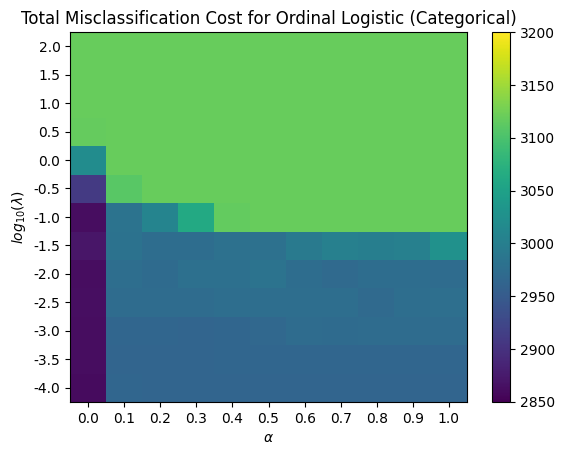

In [44]:
plt.pcolor(TC_cat_pivot, vmin = 2850, vmax = 3200, cmap = "viridis")
plt.xticks(np.arange(len(TC_cat_pivot.columns))+0.5, TC_cat_pivot.columns)
plt.yticks(np.arange(len(TC_cat_pivot.index))+0.5, np.log10(TC_cat_pivot.index).round(1))
plt.ylabel(r"$log_{10}(\lambda)$")
plt.xlabel(r"$\alpha$")
plt.title("Total Misclassification Cost for Ordinal Logistic (Categorical)")
plt.colorbar()

plt.savefig(OUTPUT_CAT_PLOT, dpi = 300)

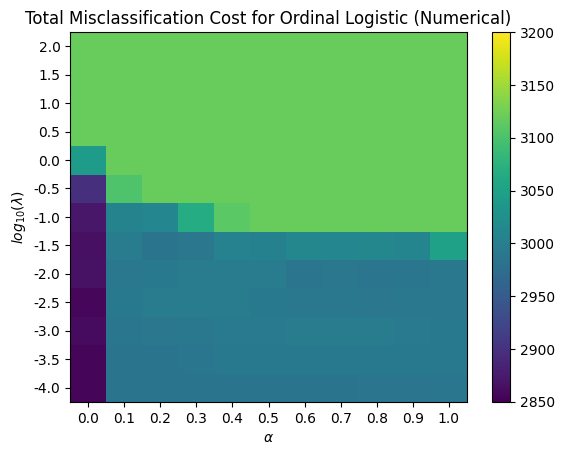

In [45]:
plt.pcolor(TC_num_pivot, vmin = 2850, vmax = 3200, cmap = "viridis")
plt.xticks(np.arange(len(TC_num_pivot.columns))+0.5, TC_num_pivot.columns)
plt.yticks(np.arange(len(TC_num_pivot.index))+0.5, np.log10(TC_num_pivot.index).round(1))
plt.ylabel(r"$log_{10}(\lambda)$")
plt.xlabel(r"$\alpha$")
plt.title("Total Misclassification Cost for Ordinal Logistic (Numerical)")
plt.colorbar()

plt.savefig(OUTPUT_NUM_PLOT, dpi = 300)